# Avaliação e Comparação dos Métodos de Busca

Este notebook avalia e compara os quatro métodos de busca implementados no sistema, sob a ótica que interessa à disciplina: **complexidade, desempenho e trade-offs**.

## O problema

O sistema recebe uma pergunta em linguagem natural (*"um hacker descobre que a realidade é uma simulação"*) e precisa recuperar, entre **42.204 sinopses** do CMU Movie Summary Corpus, aquelas semanticamente mais próximas. Há duas decisões **independentes**:

1. **Como transformar texto em vetor** (representação): TF-IDF, Word2Vec (média) ou Sentence Embeddings (MiniLM).
2. **Como encontrar os vizinhos mais próximos** (algoritmo de busca): varredura linear exata `O(N)` ou grafo HNSW aproximado (`~O(log N)`).

Combinando essas decisões, avaliamos quatro métodos:

| Método | Representação | Busca |
|---|---|---|
| TF-IDF (linear) | contagem de palavras (esparso) | linear exata |
| Word2Vec (linear) | média de vetores de palavras (100d) | linear exata |
| Sentence Emb. (linear) | MiniLM (384d) | linear exata |
| Sentence Emb. (HNSW) | MiniLM (384d) | HNSW aproximada |

Comparar métodos que só diferem na **representação** (mesma busca linear) isola o efeito da representação; comparar *Sentence Emb. linear* vs *HNSW* (mesma representação) isola o efeito do **algoritmo de busca** — o trade-off velocidade × precisão que é o coração deste trabalho.

In [1]:
import os, sys


root = os.getcwd()
while not (os.path.isdir(os.path.join(root, "data")) and os.path.isdir(os.path.join(root, "evaluation"))):
    parent = os.path.dirname(root)
    if parent == root:
        raise RuntimeError("Raiz do projeto nao encontrada — rode o Jupyter dentro do repositorio.")
    root = parent
os.chdir(root)
if root not in sys.path:
    sys.path.insert(0, root)

import pandas as pd
import matplotlib.pyplot as plt

from evaluation.benchmark import (
    build_searchers, collect_raw, aggregate, aggregate_by_category, K_VALUES,
)
from evaluation.queries import ALL_QUERIES

## Metodologia de avaliação

### Gabarito (queries de avaliação)

Avaliar qualidade exige saber a resposta certa. Montamos **55 queries** em linguagem natural, cada uma com o(s) filme(s) esperado(s) como gabarito, todos verificados contra o dataset. Elas são divididas em **quatro categorias**, o que permite analisar viés:

- **`iconic` (20)** — blockbusters de enredo muito distintivo. Caso fácil / limite superior.
- **`obscure` (15)** — filmes cult/menos populares, com a query redigida a partir da **sinopse real**. Estressam os métodos.
- **`multi` (4)** — queries de recomendação (franquias), com **vários** filmes relevantes. É a única categoria em que `recall@k` difere de `hit@k`.
- **`user` (16)** — descrições curtas e vagas escritas *"como um usuário pediria"*. Medem a utilidade no uso real e reduzem o viés de autoria.

### Métricas

- **hit@k** — a query "acerta" se **pelo menos um** filme relevante aparece entre os `k` primeiros resultados (binário, média sobre as queries). Responde: *o método coloca a resposta certa perto do topo?*
- **recall@k** — **fração** dos filmes relevantes recuperados no top-k. Com um único relevante (iconic/obscure/user) **coincide com hit@k**; só é informativo no `multi`.
- **MRR** (*Mean Reciprocal Rank*) — média de `1/posição` do primeiro acerto. Diferencia "acertou em 1º" (1.0) de "acertou em 5º" (0.2) — algo que o hit@k ignora.

## Execução das buscas

A célula abaixo é a parte pesada: carrega o MiniLM e os índices e roda os quatro métodos sobre as 55 queries (5 repetições cada). Pode levar de alguns segundos a alguns minutos. Guardamos os **dados crus** (ids recuperados + tempos) uma única vez e derivamos todas as métricas a partir deles.

In [2]:
searchers = build_searchers()
raw = collect_raw(searchers)

overall = pd.DataFrame(aggregate(raw)).set_index("method")
by_cat = pd.DataFrame(aggregate_by_category(raw))
print("Coleta concluida.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Coleta concluida.


## Benchmark 1 — Resultado geral (qualidade × velocidade)

A tabela agrega as 55 queries. `search_ms` é o tempo médio de busca por query; `hit@k` cresce com `k` (mais chances de o filme certo estar entre os `k` primeiros).

In [3]:
cols = ["search_ms"] + [f"hit@{k}" for k in K_VALUES] + ["mrr"]
overall[cols].round(3)

,search_ms,hit@1,hit@3,hit@5,hit@10,mrr
method,,,,,,
TF-IDF (linear),53.373,0.091,0.109,0.164,0.200,0.117
Word2Vec (linear),9.663,0.000,0.000,0.000,0.000,0.000
Sentence Emb. (linear),42.443,0.182,0.255,0.345,0.418,0.248
Sentence Emb. (HNSW),5.657,0.182,0.218,0.273,0.327,0.220


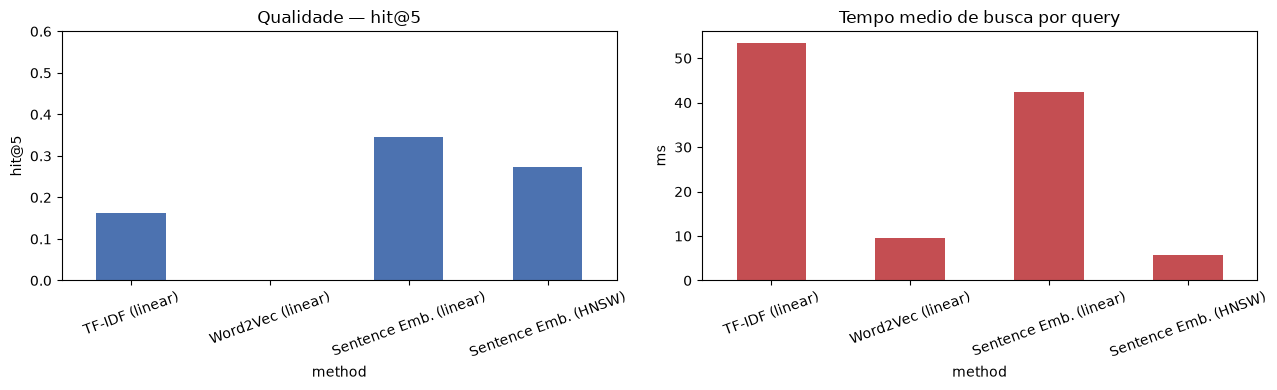

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

overall["hit@5"].plot.bar(ax=axes[0], color="#4C72B0")
axes[0].set_title("Qualidade — hit@5")
axes[0].set_ylabel("hit@5")
axes[0].set_ylim(0, 0.6)
axes[0].tick_params(axis="x", rotation=20)

overall["search_ms"].plot.bar(ax=axes[1], color="#C44E52")
axes[1].set_title("Tempo medio de busca por query")
axes[1].set_ylabel("ms")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

### Leitura

- **TF-IDF** — busca por *palavra exata*. Como as queries parafraseiam o enredo (pouco vocabulário em comum com a sinopse), acerta pouco. É o baseline não-semântico.
- **Word2Vec (média)** — treinado apenas nas 42k sinopses, com vocabulário ruidoso (`min_count=1`). A média de vetores dilui o significado e o resultado é fraquíssimo (praticamente 0). Mostra que *nem toda* representação vetorial é semanticamente útil.
- **Sentence Embeddings (MiniLM)** — melhor qualidade em todas as métricas. A rede lê a frase inteira e captura significado ("carro" ≈ "automóvel"), então paráfrases funcionam.
- **HNSW** — usa os *mesmos* vetores do MiniLM, mas com busca aproximada: qualidade levemente menor que a linear, em troca de tempo de busca muito menor (ver trade-off adiante).

## Benchmark 2 — Qualidade por categoria (análise de viés)

Aqui separamos as métricas por categoria de query. É a análise mais rica: revela **onde** cada método brilha ou falha, e não apenas uma média global.

In [5]:
order = ["iconic", "obscure", "multi", "user"]
pivot = by_cat.pivot(index="method", columns="category", values="hit@5")
pivot = pivot[[c for c in order if c in pivot.columns]]
pivot.round(2)

category,iconic,obscure,multi,user
method,,,,
Sentence Emb. (HNSW),0.30,0.27,0.75,0.12
Sentence Emb. (linear),0.35,0.47,0.75,0.12
TF-IDF (linear),0.05,0.40,0.50,0.00
Word2Vec (linear),0.00,0.00,0.00,0.00


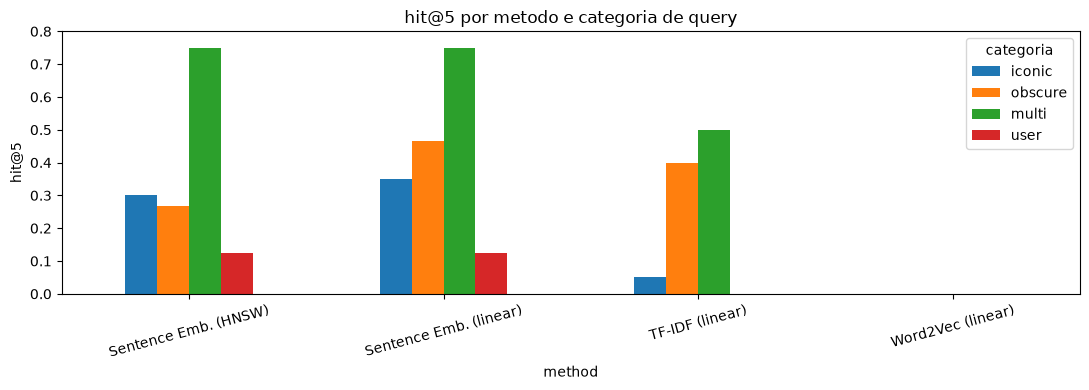

In [6]:
ax = pivot.plot.bar(figsize=(11, 4))
ax.set_title("hit@5 por metodo e categoria de query")
ax.set_ylabel("hit@5")
ax.set_ylim(0, 0.8)
ax.tick_params(axis="x", rotation=15)
ax.legend(title="categoria")
plt.tight_layout()
plt.show()

### `recall@k` e o `multi`

`recall@k` só difere de `hit@k` quando há vários relevantes. Na tabela abaixo, note que hit e recall são idênticos em `iconic`/`obscure`/`user` (um relevante só) e divergem apenas em `multi` — onde o método acha *pelo menos um* filme da franquia (hit alto) mas não a franquia inteira (recall menor).

In [7]:
by_cat[by_cat["category"] == "multi"][["method", "hit@5", "recall@5", "mrr"]].round(3).reset_index(drop=True)

,method,hit@5,recall@5,mrr
0,TF-IDF (linear),0.50,0.188,0.300
1,Word2Vec (linear),0.00,0.000,0.000
2,Sentence Emb. (linear),0.75,0.292,0.438
3,Sentence Emb. (HNSW),0.75,0.292,0.438


## Análise de complexidade

Notação: **N** = nº de documentos (42.204), **V** = tamanho do vocabulário, **d** = dimensão do vetor, **L** = comprimento médio de um documento (tokens), **Q** = comprimento da query.

O custo se divide em **offline** (pré-processamento/treino, roda uma vez) e **online** (busca, roda a cada query). Para a disciplina, o que mais importa é o custo **por busca**, pois é o que o usuário paga a cada pergunta.

### Fase offline (uma vez)

| Etapa | Tempo | Espaço | Observação |
|---|---|---|---|
| TF-IDF (fit) | `O(N·L)` | `O(nnz)` esparso | varre todos os tokens; matriz `N×V` quase toda zero |
| Word2Vec (treino) | `O(E · N·L · d)` | `O(V·d)` | `E` = épocas; janela deslizante sobre o corpus |
| Embeddings MiniLM | `O(N · C_fwd)` | `O(N·d)` | `C_fwd` = custo de um *forward* do Transformer (constante grande) |
| Índice HNSW (build) | `O(N · log N · d)` | `O(N·(d + M))` | cada inserção faz uma busca + conecta a `M` vizinhos |

A **geração dos embeddings do MiniLM domina o tempo offline** — é rodar uma rede neural 42 mil vezes. O HNSW adiciona um custo de construção `O(N log N)` por cima dos embeddings já prontos.

### Fase online (por busca)

Cada busca tem dois passos: **vetorizar a query** e **encontrar os vizinhos**.

**1. Vetorização da query**

| Método | Complexidade |
|---|---|
| TF-IDF | `O(Q)` |
| Word2Vec (média) | `O(Q·d)` |
| Sentence Emb. (MiniLM) | `O(C_fwd)` — um *forward* do Transformer |

**2. Busca dos k vizinhos mais próximos**

| Método | Complexidade | Cresce com N? |
|---|---|---|
| Linear (TF-IDF / W2V / Sentence) | `O(N·d)` + `O(N log k)` para o top-k | **Sim, linearmente** |
| HNSW | `~O(log N · d)` | **Sublinear** |

**Este é o ponto central do trabalho.** A busca linear compara a query com **todos** os `N` vetores — cresce proporcionalmente ao tamanho do acervo. Com 42 mil filmes é rápido; com dezenas de milhões seria proibitivo a cada query. O HNSW navega um grafo hierárquico e só examina uma vizinhança de tamanho `~O(log N)`, sem visitar a maioria dos vetores — por isso escala.

O preço do HNSW é ser **aproximado**: ele pode não encontrar o verdadeiro vizinho mais próximo (a busca linear encontra sempre, por construção). Trocamos **garantia de exatidão** por **tempo sublinear**.

## Trade-offs

### Velocidade × qualidade (representação)

Nos dados, o eixo **representação** define a qualidade: MiniLM ≫ TF-IDF ≫ Word2Vec. Mas essa qualidade tem custo de *vetorização*: o MiniLM precisa de um *forward* de rede neural por query (dezenas de ms), enquanto TF-IDF e Word2Vec vetorizam em `O(Q)` / `O(Q·d)` — ordens de grandeza mais barato. O método mais forte é também o mais caro para transformar a query.

### Exato × aproximado (algoritmo de busca)

Comparando as duas linhas com **os mesmos vetores MiniLM**:

- **Linear** — qualidade máxima possível daquela representação (encontra os vizinhos verdadeiros), mas `O(N·d)` por busca.
- **HNSW** — `~O(log N·d)`, sensivelmente mais rápido, ao custo de perder alguns vizinhos. Nos dados, a perda de qualidade é pequena no geral, mas **maior nos filmes obscuros** — regiões mais densas/ambíguas do espaço, onde a aproximação erra mais. É o retrato clássico do trade-off: o HNSW compensa em acervos grandes, onde a busca linear se torna inviável.

O gráfico abaixo posiciona os quatro métodos nesse plano (**canto superior-esquerdo = rápido e bom**).

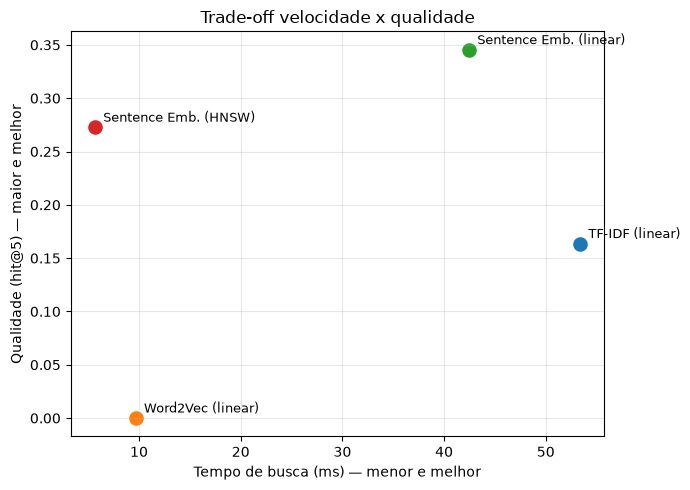

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
for method, r in overall.iterrows():
    ax.scatter(r["search_ms"], r["hit@5"], s=90)
    ax.annotate(method, (r["search_ms"], r["hit@5"]),
                textcoords="offset points", xytext=(6, 4), fontsize=9)
ax.set_xlabel("Tempo de busca (ms) — menor e melhor")
ax.set_ylabel("Qualidade (hit@5) — maior e melhor")
ax.set_title("Trade-off velocidade x qualidade")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Queries de usuário — o teste de realidade

A categoria `user` é a mais honesta sobre a utilidade prática: são descrições curtas, vagas e imperfeitas, como um usuário real digitaria (*"um panda aprende kung fu"*). O padrão nos dados é revelador:

- Com **TF-IDF** e **Word2Vec**, o hit@5 das queries de usuário é **0** — os métodos fracos simplesmente não lidam com entradas vagas.
- Com **Sentence Embeddings**, sobe para **~0.12** — a semântica do MiniLM começa a "entender" a intenção mesmo sem vocabulário compartilhado.

Ou seja: **a utilidade para o usuário real cresce à medida que a semântica melhora**. Subindo de contagem de palavras (TF-IDF) para embeddings neurais (MiniLM), o sistema sai de *"inútil para entradas vagas"* para *"ocasionalmente útil"*.

Mas é preciso honestidade: `hit@5 = 0.12` significa que, para queries de usuário, o filme certo aparece no top-5 em cerca de **1 a cada 8 buscas**. Comparado às queries bem elaboradas (iconic `0.35`, obscure `0.47`), as de usuário ficam **bem abaixo**. O aplicativo **ganha alguma utilidade real, mas ainda longe de boa** — esperado dados os recursos: modelo pequeno (MiniLM), embeddings gerados sobre texto pré-processado de forma simples, e um corpus de sinopses longas contra queries curtas.

In [9]:
# Evidência do argumento: hit@5 das queries de usuário sobe com a força semântica do método
by_cat[by_cat["category"] == "user"][["method", "hit@5", "mrr"]].round(3).reset_index(drop=True)

,method,hit@5,mrr
0,TF-IDF (linear),0.000,0.000
1,Word2Vec (linear),0.000,0.000
2,Sentence Emb. (linear),0.125,0.131
3,Sentence Emb. (HNSW),0.125,0.131


## Conclusão

- **A representação importa mais que o algoritmo de busca para a qualidade.** MiniLM domina; TF-IDF (palavra-chave) e Word2Vec (média, mal treinado) ficam muito atrás. A escolha do *como vetorizar* define o teto de qualidade.
- **O algoritmo de busca importa para a escala, não para a qualidade.** O HNSW entrega tempo de busca sublinear com perda pequena de qualidade — irrelevante em 42k filmes, decisivo em milhões. É a resposta certa quando `N` cresce.
- **Melhor qualidade custa mais tempo de vetorização** (*forward* do MiniLM), mas o HNSW recupera parte desse custo no passo de busca. A combinação **MiniLM + HNSW** é o melhor equilíbrio geral: qualidade próxima da busca exata, com o menor tempo de busca.
- **Sob a ótica do usuário real, o sistema é modestamente útil.** Queries vagas melhoram com a semântica, mas os números absolutos mostram que ainda há muito espaço — modelos maiores, melhor pré-processamento e reranqueamento seriam os próximos passos.

Em termos de complexidade, o projeto ilustra bem o trade-off que a disciplina estuda: **exato `O(N)` × aproximado `O(log N)`**, e como uma escolha estrutural (um grafo hierárquico de navegação) transforma o custo assintótico da operação mais frequente do sistema.